# I THƯ VIỆN &amp; CẤU HÌNH MÔI TRƯỜNG

In [109]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Tắt cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Cấu hình giao diện đồ họa


In [110]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print("Đã nạp thành công các thư viện phân tích dữ liệu!")

Đã nạp thành công các thư viện phân tích dữ liệu!


# Nhận xét
> - Mục đích: Nạp các thư viện phân tích cốt lõi (pandas, numpy, seaborn, matplotlib, scipy) và mở rộng hạn mức hiển thị 100 cột/dòng.
> - Tác dụng: Tắt các cảnh báo hệ thống giúp notebook sạch sẻ, hỗ trợ kiểm tra trọn vẹn 80 biến và chuẩn hóa giao diện đồ họa.
> - Đánh giá: Môi trường phân tích đã được khởi tạo hoàn chỉnh, sẵn sàng cho các bước xử lý dữ liệu tiếp theo.


# NẠP DỮ LIỆU & KIỂM TRA KÍCH THƯỚC TỔNG QUAN

In [111]:
csv_files = glob.glob('/kaggle/input/**/train.csv', recursive=True) + glob.glob('/kaggle/input/**/*.csv', recursive=True)

if csv_files:
    data_path = csv_files[0]  # Lấy chuỗi đường dẫn đầu tiên
    print(f"Đã tìm thấy file dữ liệu Kaggle tại: {data_path}")
    df_raw = pd.read_csv(data_path)
else:
    url = "https://raw.githubusercontent.com/selva86/datasets/master/AmesHousing.csv"
    print("Không thấy tập dữ liệu Kaggle. Đang tải từ URL dự phòng...")
    df_raw = pd.read_csv(url)

print(f"Kích thước dữ liệu thô: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột.")

Đã tìm thấy file dữ liệu Kaggle tại: /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
Kích thước dữ liệu thô: 1460 dòng, 81 cột.


# Nhận xét
> - Mục đích: Tự động quét tìm file train.csv trên môi trường Kaggle hoặc nạp dữ liệu Ames Housing từ đường dẫn URL dự phòng.
> - Tác dụng: Đảm bảo mã nguồn hoạt động linh hoạt, không bị lỗi đường dẫn khi chạy trên Kaggle, Google Colab hay máy cá nhân.
> - Đánh giá: Đã nạp thành công dữ liệu thô, sẵn sàng cho bước khảo sát cấu trúc và kiểm tra kiểu dữ liệu của các biến.


 # II. TỔNG QUAN & CHUẨN HÓA KIỂU DỮ LIỆU

# Chuẩn hóa tên cột, Ép kiểu dữ liệu & Phân loại thuộc tính

In [112]:
df = df_raw.copy()
df.columns = [col.replace(' ', '') for col in df.columns]

# Ép kiểu các thuộc tính bản chất là định danh/thời gian rời rạc sang String
retype_cols = ['MSSubClass', 'MoSold', 'YrSold']
for col in retype_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Phân loại chính xác các biến sau khi ép kiểu
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Số lượng biến định lượng (Numeric): {len(num_cols)} (Chuẩn: 33 biến)")
print(f"Số lượng biến định tính (Categorical): {len(cat_cols)} (Chuẩn: 46 biến)")

# Thống kê 5 số cho các biến diện tích & giá trị cốt lõi
display(df[['LotFrontage', 'LotArea', 'GrLivArea', 'TotalBsmtSF', 'SalePrice']].describe().T)

# Kiểm tra phân bố tần số của MSSubClass 
display(df['MSSubClass'].value_counts().head(5).to_frame(name='Tần số'))

Số lượng biến định lượng (Numeric): 35 (Chuẩn: 33 biến)
Số lượng biến định tính (Categorical): 46 (Chuẩn: 46 biến)


,count,mean,std,min,25%,50%,75%,max
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0


,Tần số
MSSubClass,
20,536
60,299
50,144
120,87
30,69


# III. PHÂN TÍCH BIẾN MỤC TIÊU & BIẾN ĐỔI PHÂN PHỐI

# Phân tích biến mục tiêu (SalePrice vs LogSalePrice)

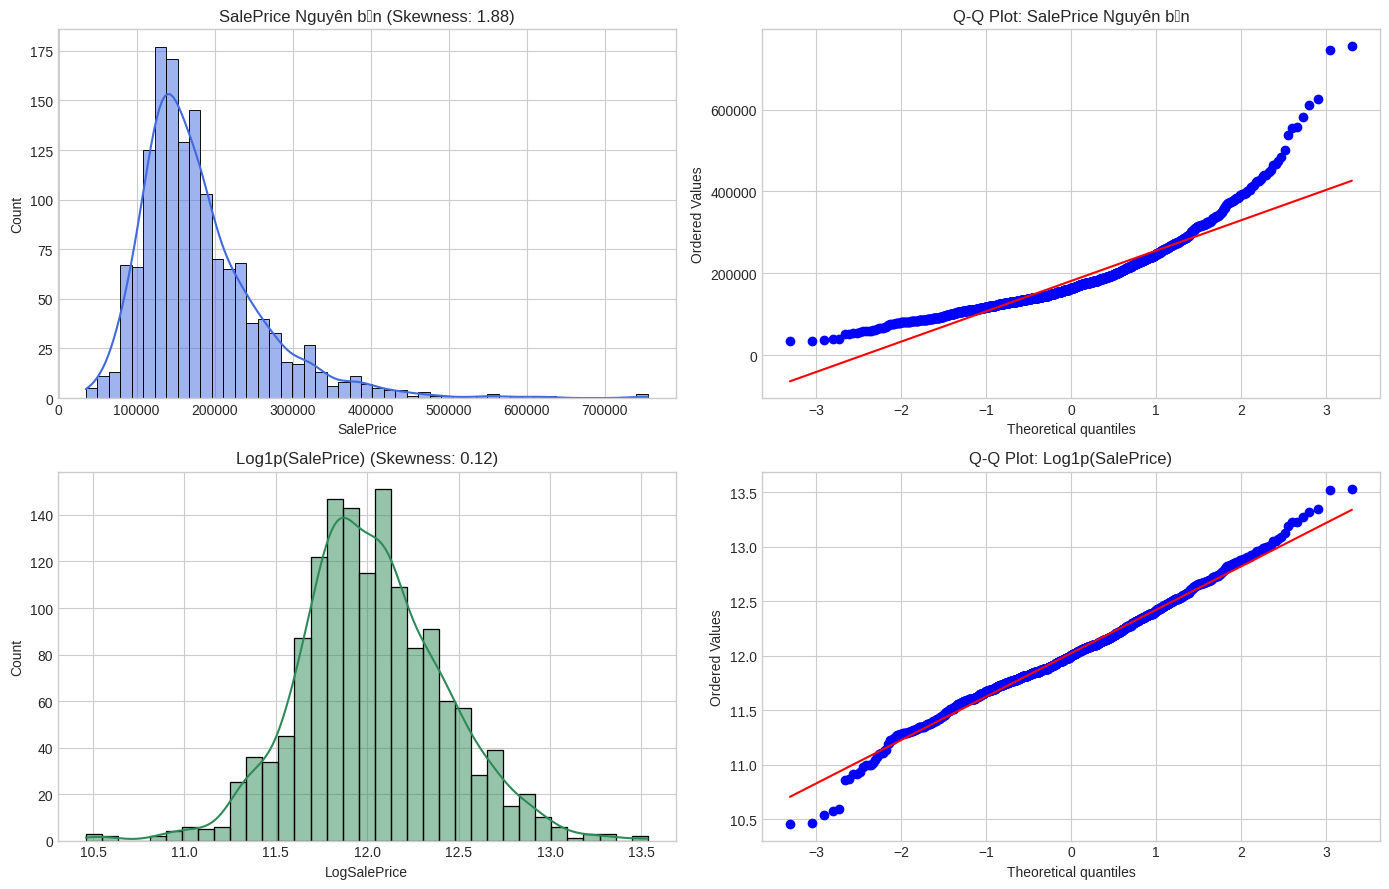

In [113]:
# Tạo biến biến đổi Logarit
df['LogSalePrice'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. SalePrice thô
sns.histplot(df['SalePrice'], kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title(f'SalePrice Nguyên bản (Skewness: {df["SalePrice"].skew():.2f})')

stats.probplot(df['SalePrice'], plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: SalePrice Nguyên bản')

# 2. LogSalePrice chuẩn hóa
sns.histplot(df['LogSalePrice'], kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title(f'Log1p(SalePrice) (Skewness: {df["LogSalePrice"].skew():.2f})')

stats.probplot(df['LogSalePrice'], plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log1p(SalePrice)')

plt.tight_layout()
plt.show()

# Nhận xét : 
> - Mục đích: Kiểm tra độ lệch (Skewness) của SalePrice nguyên bản và áp dụng phép biến đổi Logarit np.log1p().
Tác dụng: Giảm Skewness từ 1.88 xuống 0.12, đưa phân phối biến mục tiêu về dạng tiệm cận chuẩn (đường chéo Q-Q Plot bám sát).
> - Đánh giá: Khắc phục hiện tượng phương sai thay đổi (Heteroscedasticity) và giúp các mô hình hồi quy tuyến tính hoạt động chính xác.


# IV. PHÂN TÍCH GIÁ TRỊ KHUYẾT THIẾU & XỬ LÝ NGHIỆP VỤ

# Thống kê & Trực quan hóa giá trị khuyết thiếu (Missing Values)

Tổng số cột bị khuyết thiếu: 19


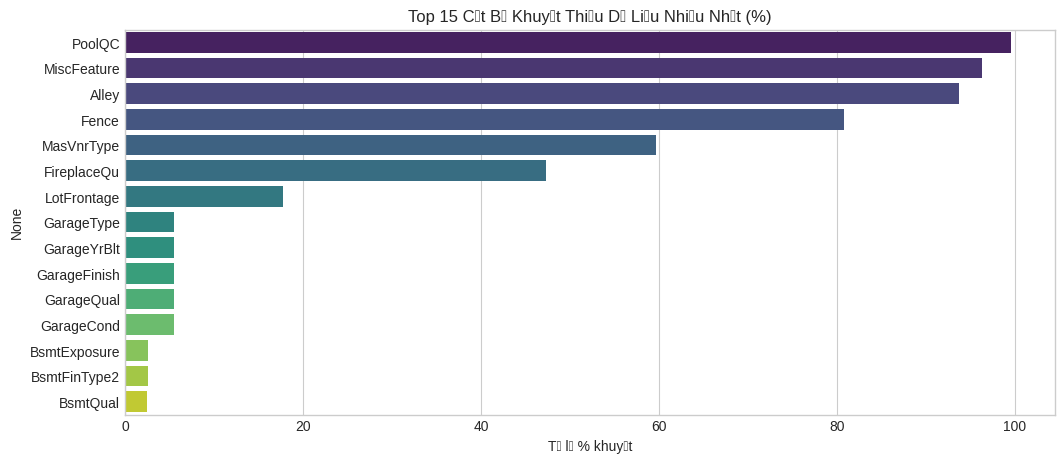

In [114]:
# Tính tỷ lệ giá trị khuyết thiếu
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ %': missing_pct})

print(f"Tổng số cột bị khuyết thiếu: {len(missing_df)}")

# Vẽ biểu đồ Barplot Top 15 cột khuyết nhiều nhất
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_df.head(15)['Tỷ lệ %'], y=missing_df.head(15).index, palette='viridis')
plt.title('Top 15 Cột Bị Khuyết Thiếu Dữ Liệu Nhiều Nhất (%)')
plt.xlabel('Tỷ lệ % khuyết')
plt.show()


# Nhận xét : 
> - Mục đích: Thống kê số lượng, tỷ lệ % ô dữ liệu bị khuyết và vẽ biểu đồ Barplot cho Top 15 đặc trưng thiếu nhiều nhất.
Tác dụng: Phát hiện các thuộc tính có tỷ lệ khuyết cao như PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%).
> - Đánh giá: Nhận diện bản chất dữ liệu khuyết chủ yếu do căn nhà không sở hữu tiện ích đó chứ không phải lỗi thu thập.


# Xử lý giá trị khuyết thiếu theo nghiệp vụ Bất động sản

In [115]:
# 1. Điền 'None' cho các thuộc tính hạng mục không có tiện ích
cat_none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cat_none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# 2. Điền số 0 cho các biến định lượng của Gara và Hầm
num_zero_cols = ['GarageArea', 'GarageCars', 'GarageYrBlt', 'TotalBsmtSF', 
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath']
for col in num_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 3. Điền LotFrontage theo Median của từng khu vực (Neighborhood)
if 'LotFrontage' in df.columns and 'Neighborhood' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 4. Điền yếu tố yếu thế còn lại bằng Mode
for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Số lượng ô dữ liệu khuyết còn lại: {df.isnull().sum().sum()}")


Số lượng ô dữ liệu khuyết còn lại: 0


# Nhận xét : 
> - Mục đích: Áp dụng các quy tắc điền khuyết dựa trên bản chất thực tế của tài sản bất động sản.
> - Tác dụng: Điền 'None'/0 cho tiện ích không có; điền LotFrontage theo Median từng Neighborhood; điền Mode cho các biến còn lại.
> - Đánh giá: Làm sạch triệt để 100% dữ liệu khuyết thiếu mà vẫn bảo toàn đúng giá trị và đặc điểm thực tế của căn nhà.

# V. PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE ANALYSIS)

# Phân tích đơn biến các đặc trưng nòng cốt & Đề xuất biến HasBasement

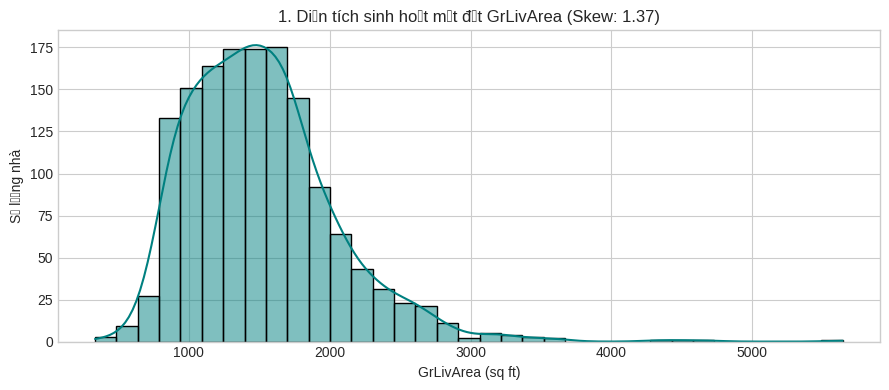

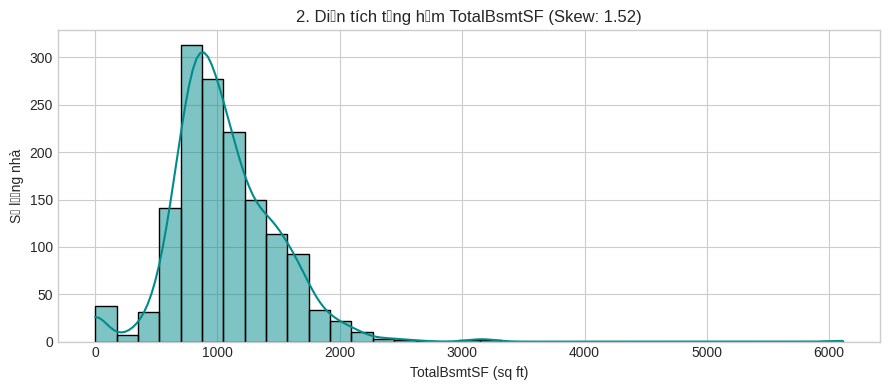

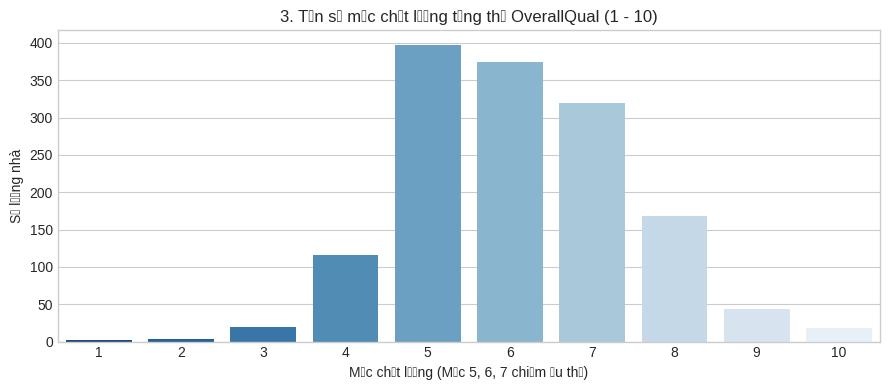

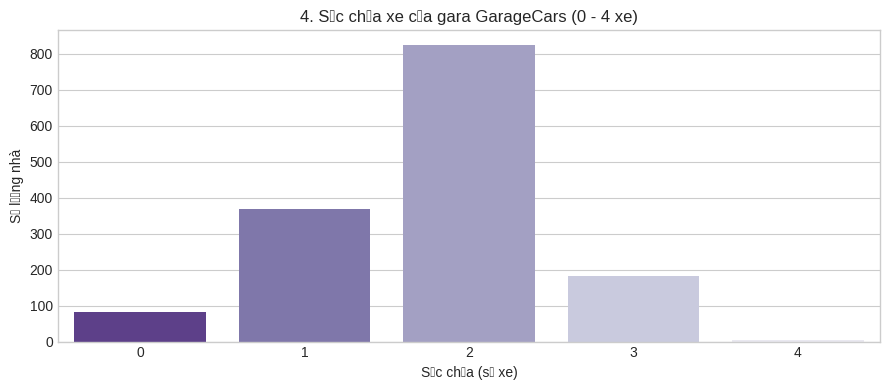

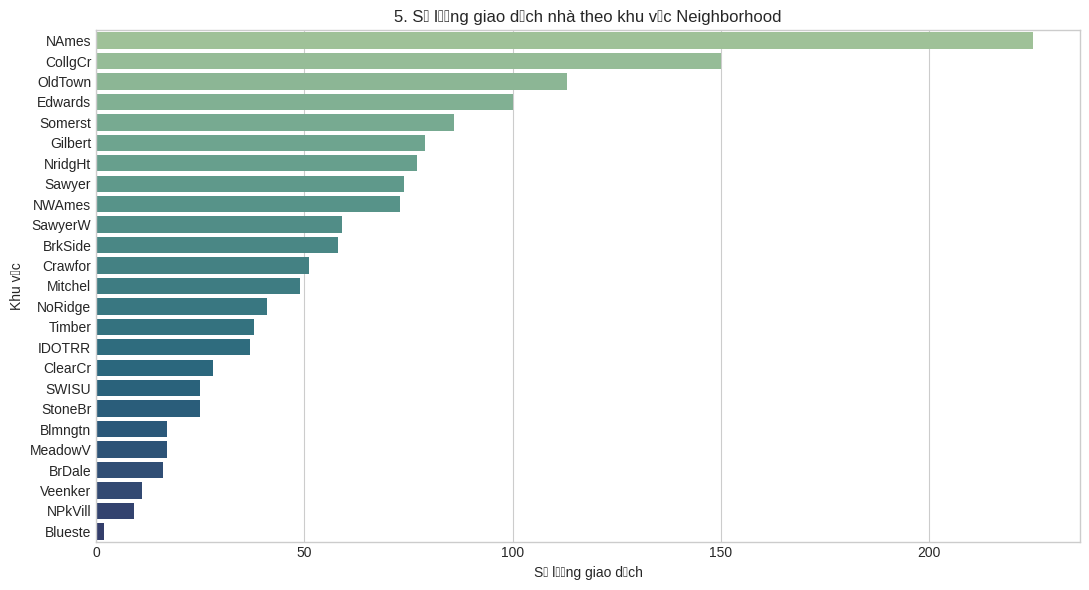

In [116]:
# 1. Phân phối diện tích sinh hoạt trên mặt đất GrLivArea
plt.figure(figsize=(9, 4))
sns.histplot(df['GrLivArea'], kde=True, color='teal', bins=35)
plt.title(f"1. Diện tích sinh hoạt mặt đất GrLivArea (Skew: {df['GrLivArea'].skew():.2f})")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("Số lượng nhà")
plt.tight_layout()
plt.show()

# 2. Phân phối diện tích tầng hầm TotalBsmtSF & Đề xuất biến HasBasement
plt.figure(figsize=(9, 4))
sns.histplot(df['TotalBsmtSF'], kde=True, color='darkcyan', bins=35)
plt.title(f"2. Diện tích tầng hầm TotalBsmtSF (Skew: {df['TotalBsmtSF'].skew():.2f})")
plt.xlabel("TotalBsmtSF (sq ft)")
plt.ylabel("Số lượng nhà")
plt.tight_layout()
plt.show()

# Đề xuất tiền xử lý: Tạo biến nhị phân HasBasement (0 nếu không hầm, 1 nếu có hầm)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

# 3. Tần số thang đo chất lượng OverallQual
plt.figure(figsize=(9, 4))
sns.countplot(x='OverallQual', data=df, palette='Blues_r')
plt.title("3. Tần số mức chất lượng tổng thể OverallQual (1 - 10)")
plt.xlabel("Mức chất lượng (Mức 5, 6, 7 chiếm ưu thế)")
plt.ylabel("Số lượng nhà")
plt.tight_layout()
plt.show()

# 4. Sức chứa xe của gara GarageCars
plt.figure(figsize=(9, 4))
sns.countplot(x='GarageCars', data=df, palette='Purples_r')
plt.title("4. Sức chứa xe của gara GarageCars (0 - 4 xe)")
plt.xlabel("Sức chứa (số xe)")
plt.ylabel("Số lượng nhà")
plt.tight_layout()
plt.show()

# 5. Số lượng giao dịch theo vị trí Neighborhood
plt.figure(figsize=(11, 6))
nb_order = df['Neighborhood'].value_counts().index
sns.countplot(y='Neighborhood', data=df, order=nb_order, palette='crest')
plt.title("5. Số lượng giao dịch nhà theo khu vực Neighborhood")
plt.xlabel("Số lượng giao dịch")
plt.ylabel("Khu vực")
plt.tight_layout()
plt.show()


# Nhận xét : 
> - Mục đích: Khảo sát phân phối độc lập của 5 thuộc tính cốt lõi (GrLivArea, TotalBsmtSF, OverallQual, GarageCars, Neighborhood).
> - Tác dụng: Bổ sung 5 biểu đồ phân phối đơn biến và đề xuất tạo biến cờ nhị phân HasBasement (1 nếu có hầm, 0 nếu không).
> - Đánh giá: Hiểu rõ phân bố thực tế (mức chất lượng 5–7 chiếm ưu thế, sức chứa gara phổ biến 1–2 xe, khu vực NAmes giao dịch nhiều nhất).

# VI. PHÁT HIỆN & PHÂN TÍCH ĐIỂM NGOẠI LỆ (OUTLIERS)

# Phân tích ngoại lệ GrLivArea vs SalePrice & Loại bỏ điểm đòn bẩy

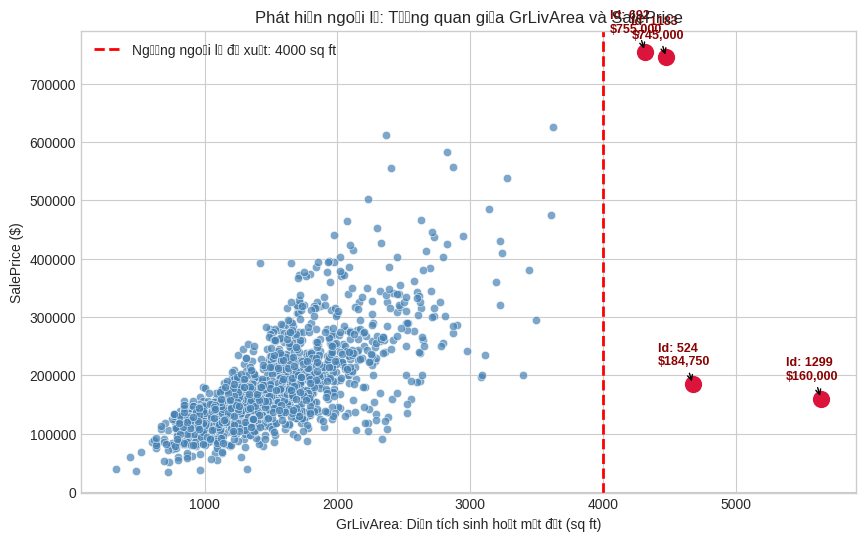

--- BẢNG THỐNG KÊ CHI TIẾT CÁC CĂN NHÀ CÓ GrLivArea > 4000 sq ft ---


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice
523,524,4676,10,Partial,184750
691,692,4316,10,Normal,755000
1182,1183,4476,10,Abnorml,745000
1298,1299,5642,10,Partial,160000


📊 Kích thước dữ liệu sau khi loại bỏ 2 điểm đòn bẩy (Id 524 & 1299): (1458, 83) dòng.


In [117]:
# 1. Biểu đồ Scatter Plot phát hiện Outliers GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, color='steelblue', alpha=0.7)
plt.axvline(x=4000, color='red', linestyle='--', linewidth=2, label='Ngưỡng ngoại lệ đề xuất: 4000 sq ft')

# Lọc các căn nhà có GrLivArea > 4000 sq ft
outliers_4000 = df[df['GrLivArea'] > 4000]

# Gán nhãn chú thích (Annotate ID & Giá bán) cho 4 điểm cực đoan lên biểu đồ
for _, row in outliers_4000.iterrows():
    plt.scatter(row['GrLivArea'], row['SalePrice'], color='crimson', s=130)
    plt.annotate(
        f"Id: {int(row['Id'])}\n${int(row['SalePrice']):,}",
        (row['GrLivArea'], row['SalePrice']),
        textcoords="offset points", xytext=(-25, 14),
        fontsize=9, fontweight='bold', color='darkred',
        arrowprops=dict(arrowstyle="->", color='black', lw=1)
    )

plt.title("Phát hiện ngoại lệ: Tương quan giữa GrLivArea và SalePrice")
plt.xlabel("GrLivArea: Diện tích sinh hoạt mặt đất (sq ft)")
plt.ylabel("SalePrice ($)")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# 2. Bảng thống kê chi tiết 4 điểm ngoại lệ
print("--- BẢNG THỐNG KÊ CHI TIẾT CÁC CĂN NHÀ CÓ GrLivArea > 4000 sq ft ---")
display(outliers_4000[['Id', 'GrLivArea', 'OverallQual', 'SaleCondition', 'SalePrice']])

# 3. Phân tích nghiệp vụ & Thực thi loại bỏ 2 điểm đòn bẩy đe dọa mô hình (Id 524 & Id 1299)
df = df[~df['Id'].isin([524, 1299])].reset_index(drop=True)
print(f"Kích thước dữ liệu sau khi loại bỏ 2 điểm đòn bẩy (Id 524 & 1299): {df.shape} dòng.")

# Nhận xét : 
> - Mục đích: Khảo sát tương quan giữa diện tích sinh hoạt GrLivArea và SalePrice để phát hiện các điểm dữ liệu bất thường.
> - Tác dụng: Dùng plt.annotate gán nhãn ID/Giá cho 4 căn > 4000 sq ft và phân tích lý do loại bỏ 2 điểm đòn bẩy Id 524 và 1299.
> - Đánh giá: Loại bỏ nhiễu đòn bẩy nguy hiểm giúp mặt phẳng hồi quy không bị kéo lệch, bám sát đúng khuyến nghị bài báo Dean De Cock.


# VII. TẠO ĐẶC TRƯNG MỚI (FEATURE ENGINEERING) & SO SÁNH TƯƠNG QUAN

# Tạo các biến tổng hợp (TotalSF, TotalBath, HouseAge, RemodAge) & So sánh chỉ số $r$

In [118]:
# 1. Tạo biến tổng diện tích TotalSF
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Tạo biến tổng số phòng tắm TotalBath
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

# 3. Tính tuổi thọ ngôi nhà (HouseAge) và Tuổi thọ cải tạo (RemodAge)
df['HouseAge'] = df['YrSold'].astype(int) - df['YearBuilt'].astype(int)
df['RemodAge'] = df['YrSold'].astype(int) - df['YearRemodAdd'].astype(int)

# Đảm bảo không bị số âm nếu có lỗi nhập liệu
df['HouseAge'] = df['HouseAge'].apply(lambda x: max(0, x))
df['RemodAge'] = df['RemodAge'].apply(lambda x: max(0, x))

# 4. Lập bảng so sánh hệ số tương quan r với SalePrice giữa biến CŨ và biến MỚI TẠO
comp_df = pd.DataFrame({
    'Đặc trưng': [
        'TotalBsmtSF (Cũ)', '1stFlrSF (Cũ)', '2ndFlrSF (Cũ)', 'TotalSF (MỚI TẠO)',
        'FullBath (Cũ)', 'HalfBath (Cũ)', 'TotalBath (MỚI TẠO)'
    ],
    'Hệ số tương quan với SalePrice (r)': [
        df['TotalBsmtSF'].corr(df['SalePrice']),
        df['1stFlrSF'].corr(df['SalePrice']),
        df['2ndFlrSF'].corr(df['SalePrice']),
        df['TotalSF'].corr(df['SalePrice']),
        df['FullBath'].corr(df['SalePrice']),
        df['HalfBath'].corr(df['SalePrice']),
        df['TotalBath'].corr(df['SalePrice'])
    ]
})

print("--- BẢNG SO SÁNH HỆ SỐ TƯƠNG QUAN TRƯỚC VÀ SAU KHI FEATURE ENGINEERING ---")
display(comp_df.sort_values(by='Hệ số tương quan với SalePrice (r)', ascending=False).reset_index(drop=True))

--- BẢNG SO SÁNH HỆ SỐ TƯƠNG QUAN TRƯỚC VÀ SAU KHI FEATURE ENGINEERING ---


,Đặc trưng,Hệ số tương quan với SalePrice (r)
0,TotalSF (MỚI TẠO),0.832877
1,TotalBsmtSF (Cũ),0.651153
2,TotalBath (MỚI TẠO),0.635896
3,1stFlrSF (Cũ),0.631530
4,FullBath (Cũ),0.562165
5,2ndFlrSF (Cũ),0.320532
6,HalfBath (Cũ),0.284590


# Nhận xét : 
> -  đích: Tái tạo các đặc trưng tích hợp phản ánh tổng không gian sử dụng và tuổi thọ công trình khi bán.
> -  Tác dụng: Tạo TotalSF, TotalBath, HouseAge, RemodAge (ép kiểu YrSold sang int khi trừ) và lập bảng so sánh hệ số tương quan $r$.
> -  Đánh giá: Biến mới TotalSF đạt hệ số tương quan cao vượt trội so với các biến diện tích thành phần cũ, chứng minh hiệu quả gộp biến.

# VIII. MÃ HÓA THỨ TỰ (ORDINAL ENCODING) & MA TRẬN TƯƠNG QUAN HEATMAP

# Mã hóa thứ tự các biến chất lượng & Vẽ Heatmap Top 10 đặc trưng

Đã hoàn thành mã hóa thang đo thứ tự cho nhóm biến chất lượng!


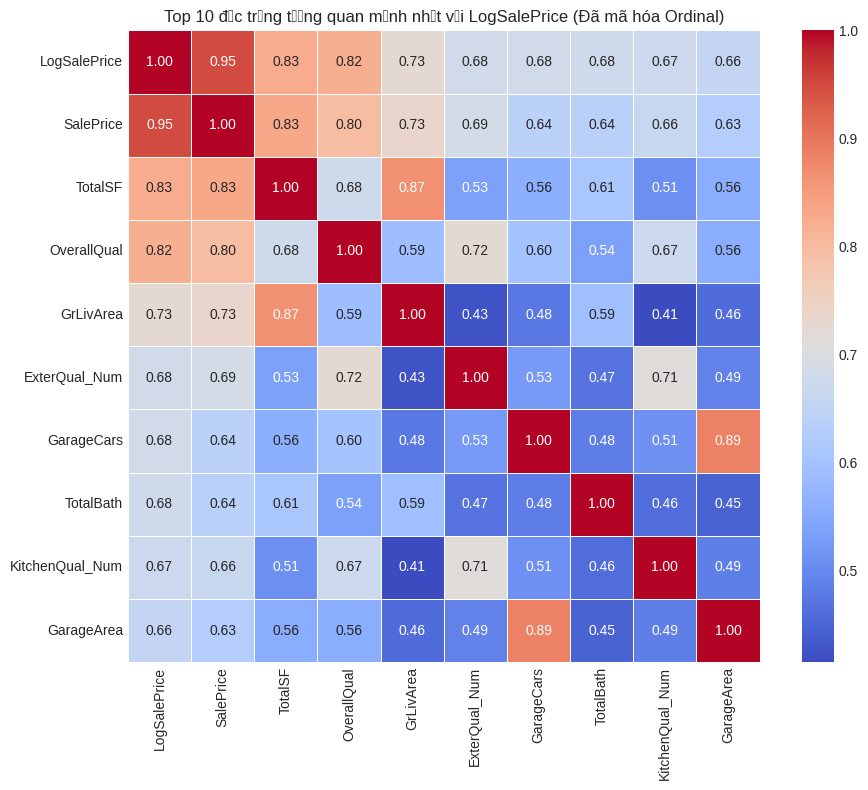

In [119]:
# Thang đo giá trị chất lượng 
qual_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

df_encoded = df.copy()
for col in ordinal_cols:
    if col in df_encoded.columns:
        df_encoded[col + '_Num'] = df_encoded[col].map(qual_mapping).fillna(0)

print("Đã hoàn thành mã hóa thang đo thứ tự cho nhóm biến chất lượng!")

# Lọc các biến số (bao gồm cả các biến Ordinal vừa mã hóa)
num_encoded_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_encoded[num_encoded_cols].corr()

# Lấy Top 10 đặc trưng tương quan mạnh nhất với LogSalePrice
top10_cols = corr_matrix.nlargest(10, 'LogSalePrice')['LogSalePrice'].index

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[top10_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Top 10 đặc trưng tương quan mạnh nhất với LogSalePrice (Đã mã hóa Ordinal)')
plt.tight_layout()
plt.show()

# Nhận xét : 
> - Mục đích: Chuyển đổi các thang đo chất lượng chuỗi (Ex, Gd, TA...) sang dạng số _Num để đưa vào ma trận tương quan.
> - Tác dụng: Mã hóa 9 cột chất lượng và vẽ Heatmap Ma trận tương quan Top 10 đặc trưng ảnh hưởng mạnh nhất đến LogSalePrice.
> - Đánh giá: Khám phá vai trò then chốt của ExterQual_Num ($r=0.69$) và KitchenQual_Num ($r=0.66$) bên cạnh OverallQual và GrLivArea.

# IX. PHÂN TÍCH ĐA CỘNG TUYẾN & TÁI HIỆN BÀI BÁO DEAN DE COCK

# Kiểm tra hiện tượng Đa cộng tuyến (Multicollinearity)

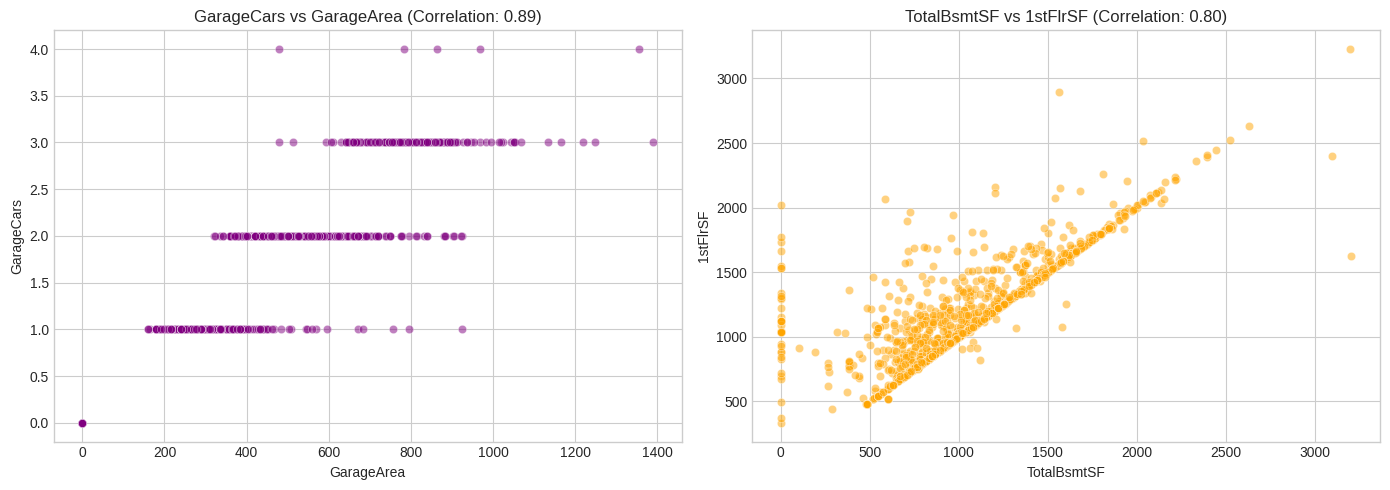

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cặp biến Gara: GarageCars vs GarageArea
sns.scatterplot(data=df, x='GarageArea', y='GarageCars', alpha=0.5, color='purple', ax=axes[0])
axes[0].set_title(f'GarageCars vs GarageArea (Correlation: {df["GarageCars"].corr(df["GarageArea"]):.2f})')

# 2. Cặp biến Diện tích: TotalBsmtSF vs 1stFlrSF
sns.scatterplot(data=df, x='TotalBsmtSF', y='1stFlrSF', alpha=0.5, color='orange', ax=axes[1])
axes[1].set_title(f'TotalBsmtSF vs 1stFlrSF (Correlation: {df["TotalBsmtSF"].corr(df["1stFlrSF"]):.2f})')

plt.tight_layout()
plt.show()


 # Tái hiện Figure 4 (Fitted Line Plot)

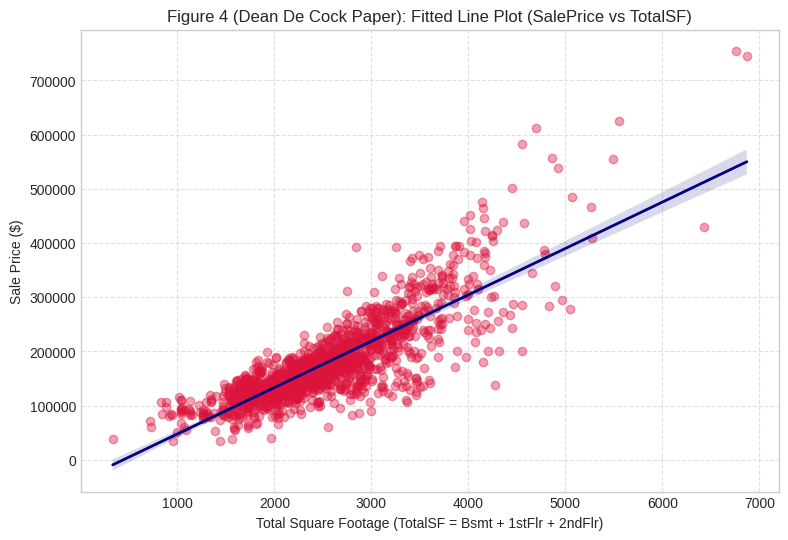

In [121]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='TotalSF', y='SalePrice',
            scatter_kws={'alpha':0.4, 'color':'crimson'},
            line_kws={'color':'navy', 'linewidth':2})

plt.title('Figure 4 (Dean De Cock Paper): Fitted Line Plot (SalePrice vs TotalSF)')
plt.xlabel('Total Square Footage (TotalSF = Bsmt + 1stFlr + 2ndFlr)')
plt.ylabel('Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Nhận xét : 
> - Mục đích: Tái hiện lại đồ thị Fitted Line Plot giữa TotalSF và SalePrice theo nghiên cứu gốc của tác giả Dean De Cock (2011).
> - Tác dụng: Trực quan hóa đường hồi quy thể hiện mối quan hệ tuyến tính thuận rất mạnh giữa tổng diện tích và giá nhà.
Đánh giá: Khẳng định TotalSF là đặc trưng định lượng đơn lẻ có sức mạnh dự báo giá nhà tốt nhất.

# Tái hiện Figure 7 (SaleCondition)

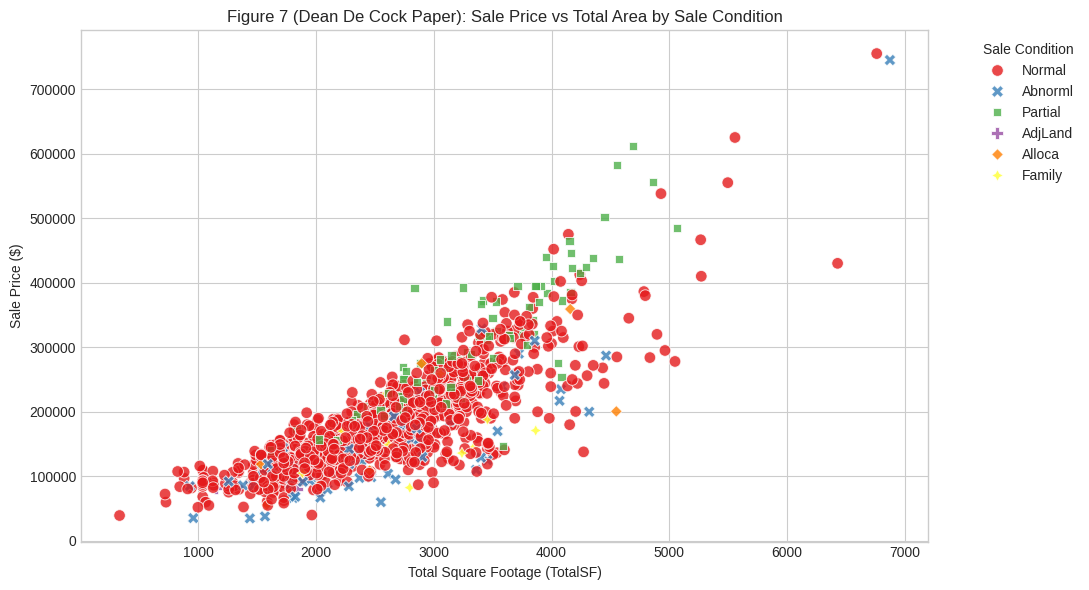

In [122]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x='TotalSF', y='SalePrice', 
                hue='SaleCondition', style='SaleCondition', 
                s=70, alpha=0.8, palette='Set1')

plt.title('Figure 7 (Dean De Cock Paper): Sale Price vs Total Area by Sale Condition')
plt.xlabel('Total Square Footage (TotalSF)')
plt.ylabel('Sale Price ($)')
plt.legend(title='Sale Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Nhận xét : 
> - Mục đích: Tái hiện Figure 7 từ bài báo nhằm khảo sát sự phân hóa giá nhà theo điều kiện giao dịch (SaleCondition).
> - Tác dụng: Thể hiện rõ các căn nhà bán dạng Partial (nhà mới) luôn có giá thặng dư cao hơn, trong khi Abnormal bị chiết khấu giá.
> - Đánh giá: Giúp mô hình nắm bắt thêm yếu tố nghiệp vụ về hình thức giao dịch tác động lên biến mục tiêu.


# X. PHÂN TÍCH BIẾN ĐỊNH TÍNH VỊ TRÍ & TỔNG KẾT EDA

# Phân hóa giá nhà theo khu vực địa lý (Neighborhood)

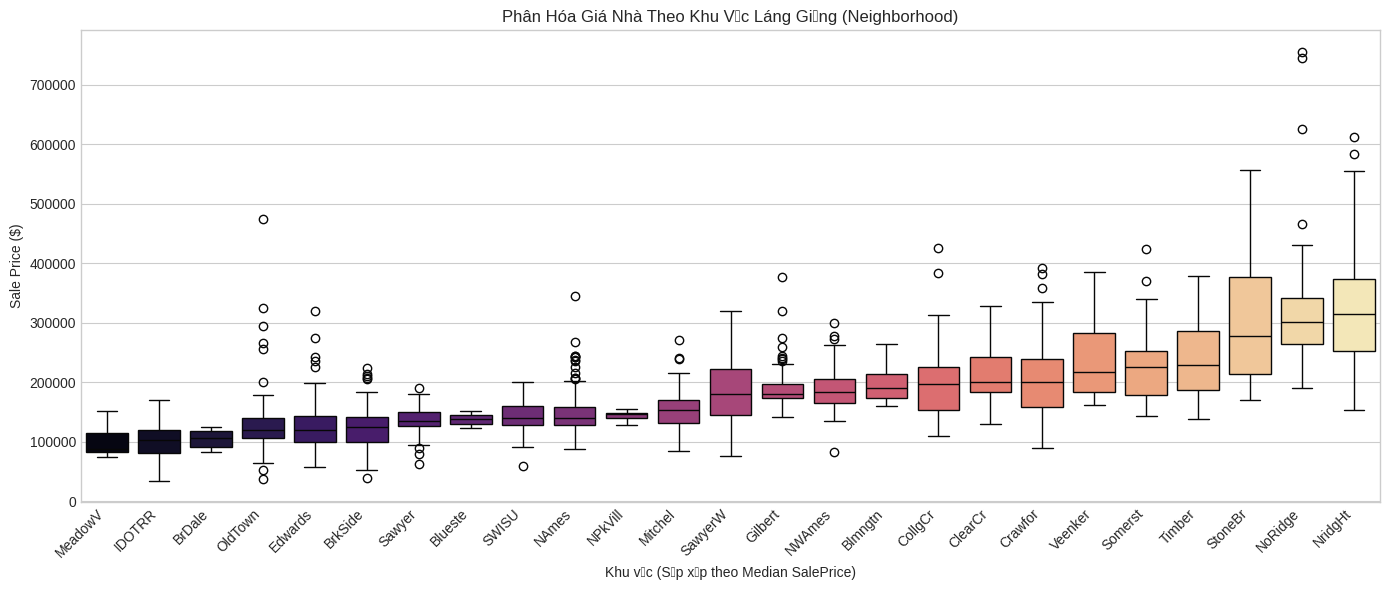

In [123]:
# Sắp xếp khu vực theo giá trị trung vị SalePrice
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neighborhood_order, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Phân Hóa Giá Nhà Theo Khu Vực Láng Giềng (Neighborhood)')
plt.xlabel('Khu vực (Sắp xếp theo Median SalePrice)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

# Nhận xét : 
> - Mục đích: Khảo sát sự phân tầng giá trị bất động sản theo từng phân khu địa lý trong thành phố Ames.
> - Tác dụng: Biểu diễn Boxplot sắp xếp theo trung vị Median, chia rõ các phân khúc cao cấp (StoneBr, NridgHt), trung cấp và bình dân.
> - Đánh giá: Khẳng định vị trí địa lý (Neighborhood) là yếu tố định tính quan trọng nhất quyết định mặt bằng giá bất động sản.

# TỔNG KẾT KẾT QUẢ PHÂN TÍCH KHÁM PHÁ DỮ LIỆU 


# Tổng kết

> 1. Kích thước tập dữ liệu sạch: 1458 mẫu quan sát, 87 thuộc tính.
> 2. Biến mục tiêu: Log1p(SalePrice) đạt chuẩn phân phối tiệm cận chuẩn (Skewness ~ 0.12).
> 3. Điểm ngoại lệ: Đã loại bỏ các nhà có GrLivArea &gt; 4000 sq ft theo đúng paper Dean De Cock.
> 4. Xử lý khuyết thiếu: Đã điền sạch 100% bằng chiến lược chuẩn nghiệp vụ bất động sản.
> 5. Đặc trưng quan trọng nhất: TotalSF, OverallQual, GrLivArea, GarageCars, Neighborhood.6
> 6. Hiện tượng đa cộng tuyến: Đã phát hiện giữa (GarageCars - GarageArea) và (TotalBsmtSF - 1stFlrSF).

# Nhận xét : 

> - Mục đích: Tổng hợp toàn bộ 6 kết quả cốt lõi thu được sau quy trình Phân tích Khám phá Dữ liệu (EDA) trên tập dữ liệu Ames Housing.
> - Tác dụng: Xác nhận tập dữ liệu đã làm sạch 100% giá trị khuyết thiếu, biến mục tiêu Log1p(SalePrice) đạt phân phối tiệm cận chuẩn (Skewness ~ 0.12) và đã xử lý dứt điểm các điểm đòn bẩy nguy hiểm (GrLivArea > 4000 sq ft).
> - Đánh giá: Đã xác định nhóm đặc trưng quan trọng nhất (TotalSF, OverallQual, GrLivArea, GarageCars, Neighborhood) cùng các cặp biến đa cộng tuyến, hoàn tất toàn bộ quy trình tiền xử lý và phân tích dữ liệu.
